In [1]:
import torch

# si ringrazia la gentile partecipazione del server Linux per la generazione del dataset (METIS non funziona su Windows)
#dataset = RedditSubGraphDataset(path='Reddit', num_graphs=1000, task_type='a')

dataset = torch.load("reddit_task3_clusters_a.pt", weights_only=False)
# classe 1: sopra media = 370 grafi
# classe 0: sotto media = 630 grafi

In [2]:
from torch_geometric.loader import DataLoader

batch_size = 64

#Creazione dei DataLoader per il training, la validazione e il test
train_loader = DataLoader(dataset["train"], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset["val"], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset["test"], batch_size=batch_size, shuffle=False)

Tentativo GCN

In [3]:
from utils_task3_a import HierarchicalGCNClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = HierarchicalGCNClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_GCN.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 15.01it/s]


Epoch 1/50 - Train Loss: 0.8477 - Val Loss: 0.8161 - Balanced Accuracy: 0.6997 - F1 Score: 0.7200
Nuovo miglior modello salvato con Val Loss: 0.8161
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 22.24it/s]


Epoch 2/50 - Train Loss: 0.7903 - Val Loss: 0.7722 - Balanced Accuracy: 0.6933 - F1 Score: 0.7292
Nuovo miglior modello salvato con Val Loss: 0.7722
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 23.86it/s]


...

Epoch 14/50 - Train Loss: 0.1350 - Val Loss: 0.6739 - Balanced Accuracy: 0.8340 - F1 Score: 0.8408
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 20.82it/s]


Epoch 15/50 - Train Loss: 0.1098 - Val Loss: 0.7459 - Balanced Accuracy: 0.8260 - F1 Score: 0.8312
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 23.70it/s]

Epoch 16/50 - Train Loss: 0.1095 - Val Loss: 0.6947 - Balanced Accuracy: 0.8363 - F1 Score: 0.8496
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


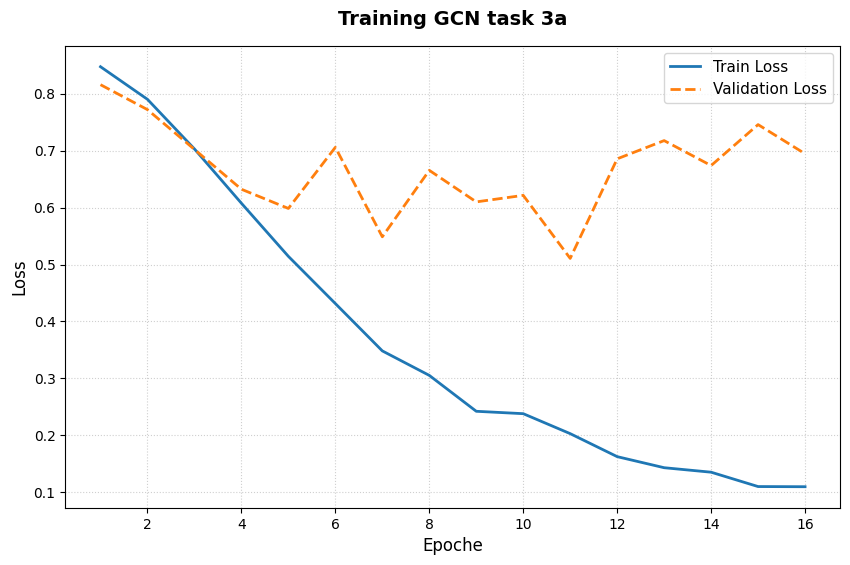

In [4]:
from utils_task1 import plot_history

plot_history(history,"Training GCN task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 21.04it/s]

Test Loss: 0.3324 - Balanced Accuracy: 0.8745 - F1 Score: 0.8714


[]

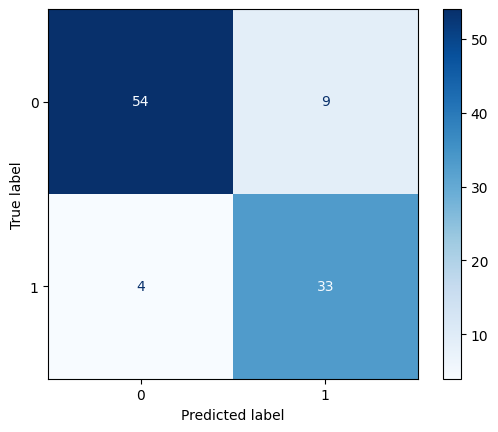

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device, test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

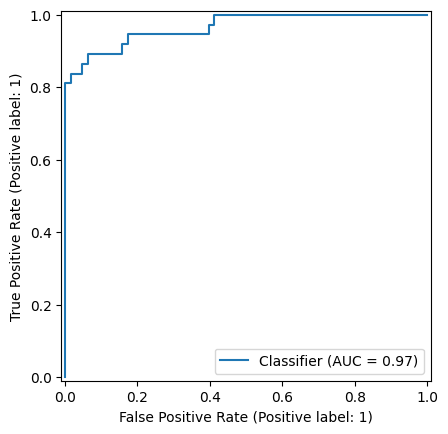

In [6]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()

Tentativo SAGE

In [7]:
from utils_task3_a import HierarchicalSAGEConvClassifier,train_loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = HierarchicalSAGEConvClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_SAGE.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.08it/s]


Epoch 1/50 - Train Loss: 0.8487 - Val Loss: 0.8316 - Balanced Accuracy: 0.5706 - F1 Score: 0.4302
Nuovo miglior modello salvato con Val Loss: 0.8316
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 27.93it/s]


Epoch 2/50 - Train Loss: 0.8120 - Val Loss: 0.7907 - Balanced Accuracy: 0.5742 - F1 Score: 0.5945
Nuovo miglior modello salvato con Val Loss: 0.7907
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 30.06it/s]


...

Epoch 13/50 - Train Loss: 0.4193 - Val Loss: 0.5795 - Balanced Accuracy: 0.7896 - F1 Score: 0.7740
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 28.89it/s]


Epoch 14/50 - Train Loss: 0.3478 - Val Loss: 0.6156 - Balanced Accuracy: 0.8316 - F1 Score: 0.8319
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 28.59it/s]

Epoch 15/50 - Train Loss: 0.2985 - Val Loss: 0.6379 - Balanced Accuracy: 0.8078 - F1 Score: 0.8030
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


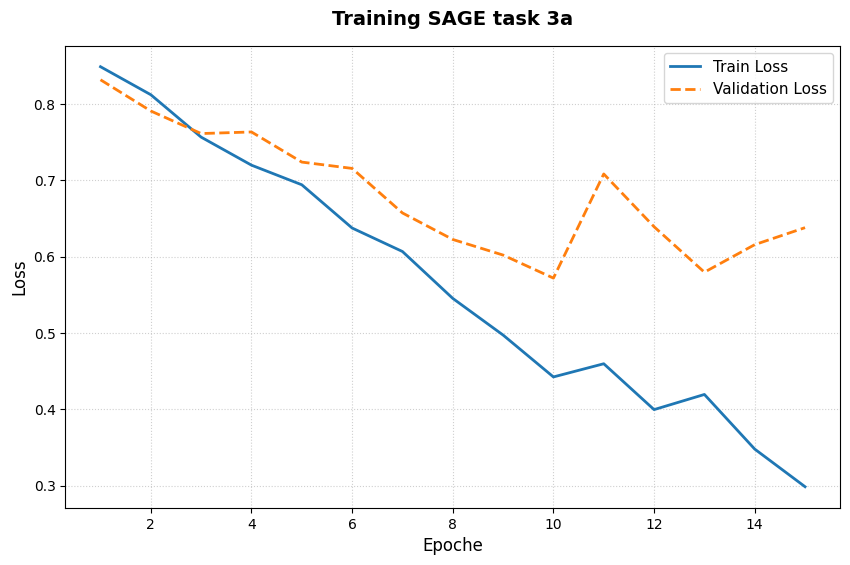

In [8]:
from utils_task1 import plot_history

plot_history(history,"Training SAGE task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 26.02it/s]

Test Loss: 0.4947 - Balanced Accuracy: 0.8372 - F1 Score: 0.8323


[]

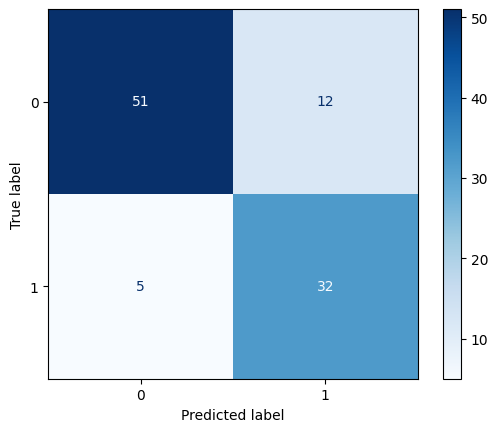

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

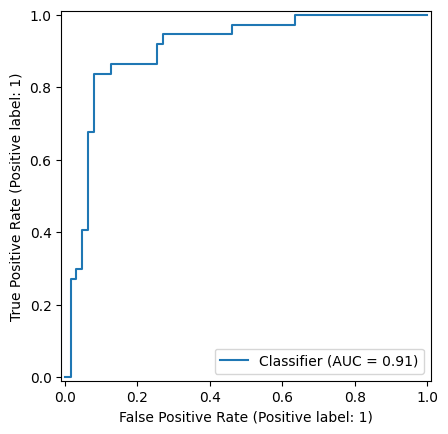

In [10]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()

Tentativo GAT

In [11]:
from utils_task3_a import HierarchicalGATClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = HierarchicalGATClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_GAT.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  9.07it/s]


Epoch 1/50 - Train Loss: 0.8799 - Val Loss: 0.8540 - Balanced Accuracy: 0.5577 - F1 Score: 0.5200
Nuovo miglior modello salvato con Val Loss: 0.8540
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  8.38it/s]


Epoch 2/50 - Train Loss: 0.8149 - Val Loss: 0.8304 - Balanced Accuracy: 0.5847 - F1 Score: 0.5374
Nuovo miglior modello salvato con Val Loss: 0.8304
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  8.76it/s]


...

Epoch 8/50 - Train Loss: 0.2606 - Val Loss: 0.8277 - Balanced Accuracy: 0.7776 - F1 Score: 0.7906
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  9.10it/s]


Epoch 9/50 - Train Loss: 0.1833 - Val Loss: 1.7494 - Balanced Accuracy: 0.7211 - F1 Score: 0.7400
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  9.17it/s]

Epoch 10/50 - Train Loss: 0.1621 - Val Loss: 1.4617 - Balanced Accuracy: 0.7179 - F1 Score: 0.7457
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


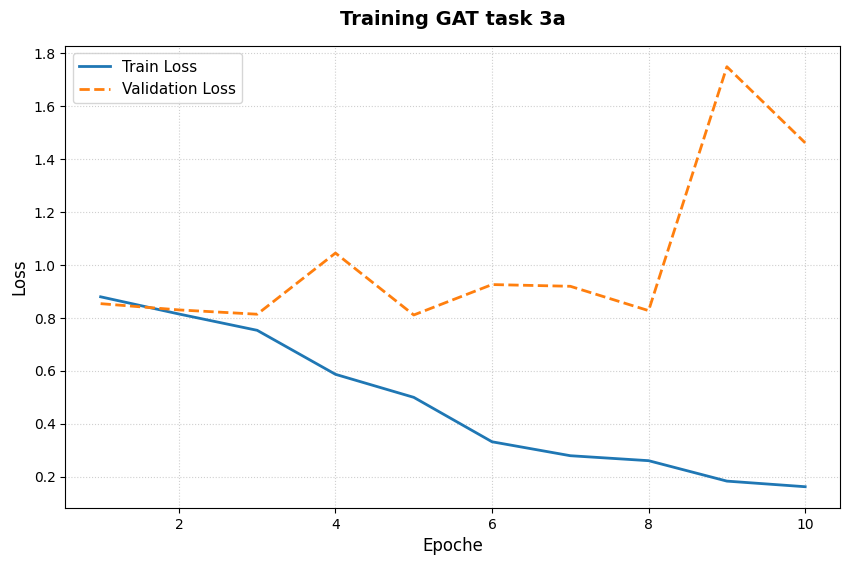

In [12]:
from utils_task1 import plot_history

plot_history(history,"Training GAT task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  8.55it/s]

Test Loss: 0.6857 - Balanced Accuracy: 0.6909 - F1 Score: 0.7230


[]

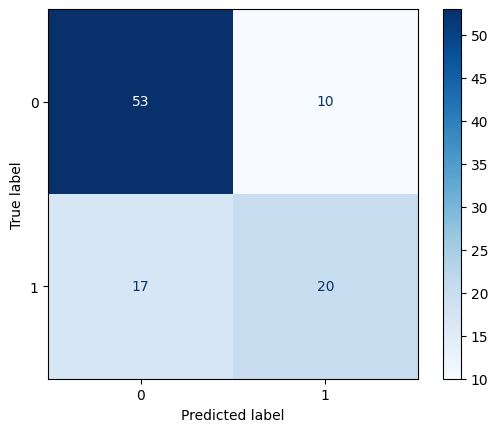

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

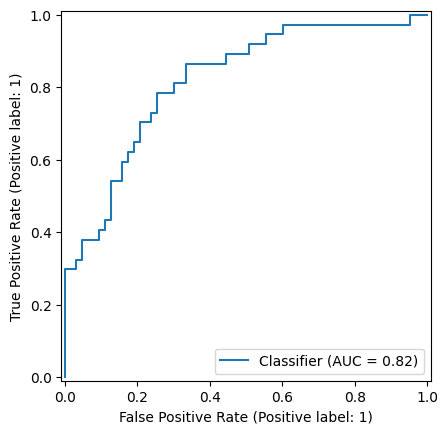

In [14]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()

Tentativo GIN

In [15]:
from utils_task3_a import HierarchicalGINClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = HierarchicalGINClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3a_GIN.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.51it/s]


Epoch 1/50 - Train Loss: 0.5027 - Val Loss: 0.4858 - Balanced Accuracy: 0.8514 - F1 Score: 0.8848
Nuovo miglior modello salvato con Val Loss: 0.4858
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 28.20it/s]


Epoch 2/50 - Train Loss: 0.2469 - Val Loss: 0.2711 - Balanced Accuracy: 0.9189 - F1 Score: 0.9387
Nuovo miglior modello salvato con Val Loss: 0.2711
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.21it/s]


...

Epoch 7/50 - Train Loss: 0.0854 - Val Loss: 0.1364 - Balanced Accuracy: 0.9650 - F1 Score: 0.9699
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 30.96it/s]


Epoch 8/50 - Train Loss: 0.0899 - Val Loss: 0.1223 - Balanced Accuracy: 0.9571 - F1 Score: 0.9600
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.77it/s]

Epoch 9/50 - Train Loss: 0.0818 - Val Loss: 0.1132 - Balanced Accuracy: 0.9436 - F1 Score: 0.9499
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


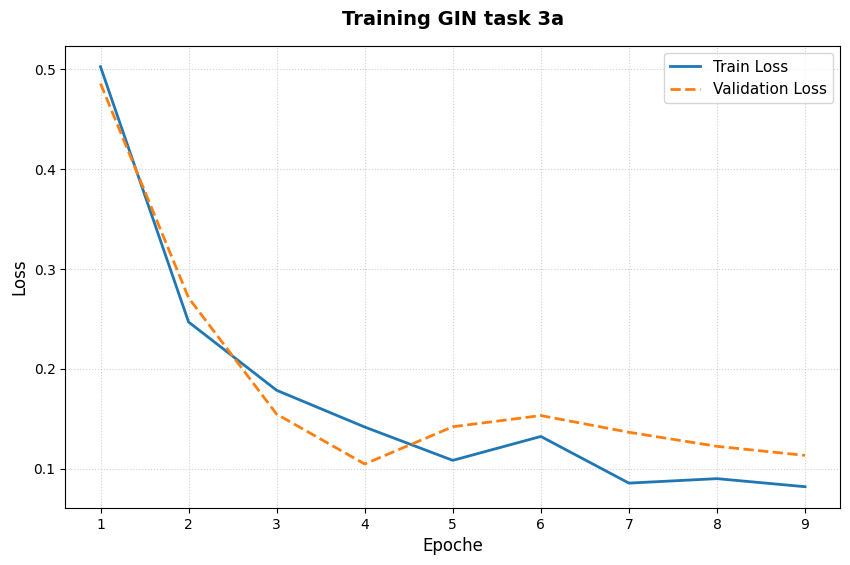

In [16]:
from utils_task1 import plot_history

plot_history(history,"Training GIN task 3a")

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 27.49it/s]

Test Loss: 0.1208 - Balanced Accuracy: 0.9865 - F1 Score: 0.9900


[]

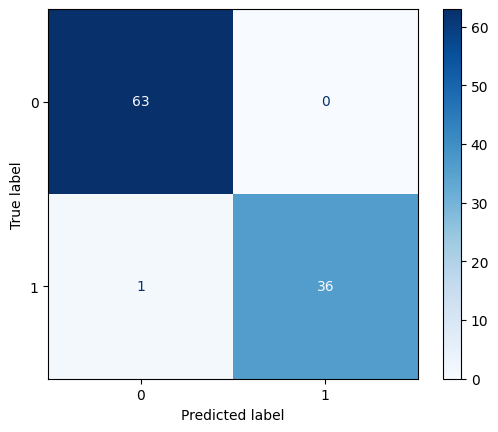

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
import matplotlib.pyplot as plt
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device,test=True)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
ConfusionMatrixDisplay(test_metrics['confusion_matrix'], display_labels=[0,1]).plot(cmap='Blues')
plt.plot()

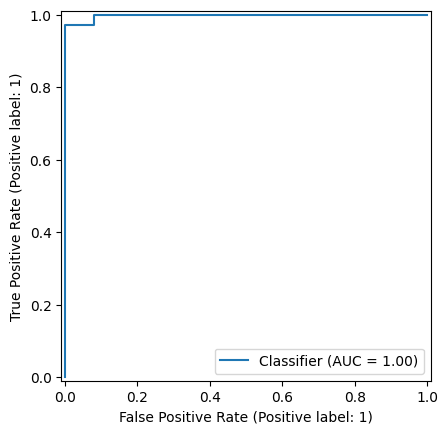

In [18]:
RocCurveDisplay.from_predictions(test_metrics['y_true'], test_metrics['y_pred'], pos_label=1)
plt.plot()
torch.cuda.empty_cache()